<a href="https://colab.research.google.com/github/augustojrr/redes-neurais-UFPI/blob/main/Adaline_Porta_AND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ATIVIDADE REDES NEURAIS

---

##Assunto: Adaline
##Aluno: Augusto César de Sousa Passos Júnior

---
#Introdução:
###O ADALINE (Adaptive Linear Neuron ou Neurônio Linear Adaptativo) é um tipo de rede neural artificial de camada única, desenvolvido por Bernard Widrow e Ted Hoff em 1960, pouco depois do Perceptron de Rosenblatt.

###A grande diferença e inovação do Adaline em relação ao Perceptron original reside na sua forma de aprendizado:

* Função de Ativação Linear: Enquanto o Perceptron ajusta seus pesos com base na saída binária final (0 ou 1), o Adaline utiliza a saída linear (o somatório bruto antes da ativação) para calcular o erro.

* Regra de Delta (Widrow-Hoff): Ele introduziu o uso do Gradiente Descendente para minimizar o Erro Quadrático Médio (MSE). Isso significa que o neurônio tenta reduzir a "distância" entre o valor real e o valor esperado.

* Convergência: Por trabalhar com valores contínuos no ajuste, o Adaline é mais estável e consegue encontrar a "melhor" linha de separação (a que minimiza o erro total), mesmo que os dados não sejam perfeitamente separáveis.

###Em resumo, o Adaline serviu como base fundamental para as redes neurais modernas, estabelecendo o padrão de como otimizamos modelos através da minimização de funções de custo.


---

#Objetivo:
###Nesta atividade, temos como objetivo geral treinar uma ADALINE para se comportar como uma porta AND. E temos alguns objetivos especificos também, que são:

* Plotar a reta de separação entre as classes durante cada interação de treinamento.

* Mostrar curva de aprendizagem (Erro x Época)

* Mostrar a atualização de Pesos e do Bias.

* Treinar o algoritmo com dados de teste aleatórios e plotar figura colorida de separação


---












#Código onde temos o Perceptron com as devidas alterações para perfomar como uma ADALINE, e os códigos que mostram os 3 primeiros objetivos específicos.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


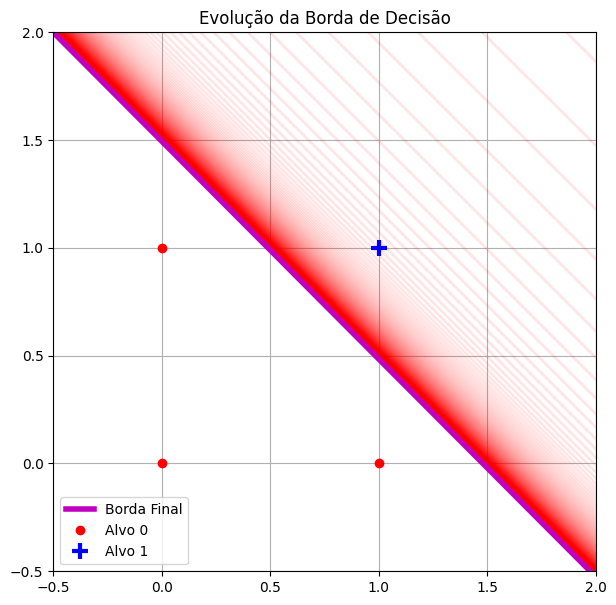

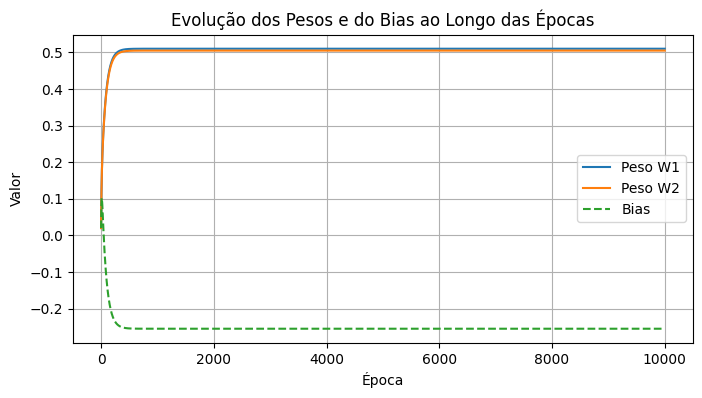

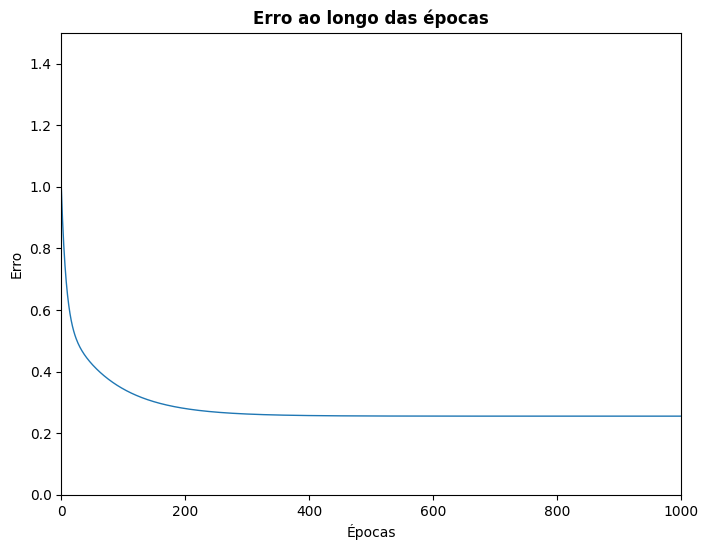

In [ ]:
def linear(x): # Implementação da função linear
  if x >= 0.5:
    return 1

  elif -0.5 <= x <= 0.5:
    return 0

def perceptron(input,target,weight,bias): # Criando a função perceptron com os parâmetros (entradas, alvos, pesos,
                                          # bias).
  fator_aprendizado = 0.02 # passo que o algoritmo dá ao ajustar os pesos e o bias para reduzir o erro.
  somatorio = bias # inicializando a variavel somatorio com o valor de bias, pois posteriormente vamos somar as
                   # entradas com os seus respectivos pesos e no final precisaremos somar com o bias.

  for i in range(len(input)): # um for que percorre cada entrada individual
                              # (neste caso, as 2 entradas x1 e x2 de cada exemplo).
    a = (input[i]*weight[i]) # variavel que armazena o valor de cada entrada vezes o seu peso correspondente.
    somatorio += a # somando os valores (entrada x peso) na variavel somatorio, que no final já estará somado com
                   # o valor da bias.

  erro = target - somatorio # Cálculo do erro linear (Regra de Delta) para o Adaline.

  new_weight = [] # lista vazia para armazenar os novos pesos.

  for i in range(len(weight)): # um for com range correspondente a quantidade de pesos.
    weight_new = weight[i] + (fator_aprendizado*erro*input[i]) # calculando o novo_peso, que será o peso_antigo +
                                             # + (erro x entrada_correspondente x fator_aprendizado).
    new_weight.append(weight_new) # função append para salvar o valor do novo_peso na lista de novos_pesos.

  bias_new = bias + (erro*fator_aprendizado) # calculo da nova_bias, que é a antiga_bias + (erro*fator_aprendizado)

  return new_weight, bias_new, erro # a nossa função perceptron nós retorna: novos_pesos, nova_bias e o erro.


inputs = [[0,0],[0,1],[1,0],[1,1]] # lista dos meus pares de entradas.
targets = [0,0,0,1] # lista dos meu alvos, correspondentes aos pares de entradas
w = [0,0] # inicializo meus pesos em 0, como só são duas entradas, apenas dois pesos
b = 0 # inicializo a minha bias em 0

hist_erros = [] # Lista para o historico de erros
hist_pesos = [] # Lista para o historico de pesos
hist_bias = []  # Lista para o hisotorico de bias
hist_erro_amostra = [] # Nova lista para salvar cada erro individual

for epoca in range(10000): # um for com 10000 epocas, que seriam 10000 ciclos de treinamento.
  erros_na_epoca = 0
  precisao = 0.2 # parametro para quantificarmos os erros em uma epoca.

  for i in range(len(inputs)):
    w, b, e = perceptron(inputs[i],targets[i],w,b) # aqui, eu coloco 3 variaveis para salvarem os valores retornados
                                                   # na função perceptron, e a cada nova iteração, os novos valores
                                                   # de peso, e de bias, já são automaticamente utilizados.

    if abs(e) >= precisao: # compara o valor absoluto do erro com o meu parametro de precisão
            erros_na_epoca += 1

  hist_erros.append(erros_na_epoca) # Salva os erros da epoca na lista de historico de Erros
  hist_pesos.append(list(w)) # Salva os valores dos pesos utilizados na lista de historico de Pesos.
  hist_bias.append(b) # Salva os valores de Bias utilizados na lista de  historico de Bias.
  hist_erro_amostra.append(abs(e)) # Salva o erro absoluto da última amostra da época em uma lista.

##########################################################################################################################

import numpy as np
import matplotlib.pyplot as plt

# Configuração do gráfico
plt.figure(figsize=(7,7))
x_reta = np.linspace(-0.5, 2, 10)

# 1. Plotar as bordas de decisão históricas (as tentativas)
for i in range(len(hist_pesos)):
    w1, w2 = hist_pesos[i]
    bias_hist = hist_bias[i]

    if w2 != 0:
        # Adicionamos o +0.5 para alinhar com sua função de ativação
        y_reta = (-w1 * x_reta - bias_hist + 0.5) / w2
        plt.plot(x_reta, y_reta, color='red', alpha=0.1, linewidth=2)

# 2. Destacar a ÚLTIMA borda (a final) em Magenta
w1_f, w2_f = hist_pesos[-1]
b_f = hist_bias[-1]

# Fórmula corrigida: x2 = (-w1*x1 - b + limiar) / w2
y_final = (-w1_f * x_reta - b_f + 0.5) / w2_f
plt.plot(x_reta, y_final, 'm-', linewidth=4, label='Borda Final')

# 3. Plotar os pontos da Porta AND
plt.plot([0, 0, 1], [0, 1, 0], 'ro', label='Alvo 0')
plt.plot([1], [1], 'b+', markersize=12, markeredgewidth=3, label='Alvo 1')

plt.xlim(-0.5, 2)
plt.ylim(-0.5, 2)
plt.title("Evolução da Borda de Decisão")
plt.legend()
plt.grid(True)
plt.show()

## Evolução dos Parâmetros ao Longo das Épocas
plt.figure(figsize=(8, 4))
plt.plot([p[0] for p in hist_pesos], label='Peso W1')
plt.plot([p[1] for p in hist_pesos], label='Peso W2')
plt.plot(hist_bias, label='Bias', linestyle='--')
plt.title("Evolução dos Pesos e do Bias ao Longo das Épocas")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

# Erro
plt.figure(figsize=(8, 6))

# Plotando os erros de cada iteração
plt.plot(hist_erro_amostra, linewidth=1)

# Configurações de titulos
plt.title("Erro ao longo das épocas", fontweight='bold')
plt.xlabel("Épocas")
plt.ylabel("Erro")

# Ajustando os limites dos eixos
plt.xlim(0, 1000)
plt.ylim(0, 1.5)

plt.grid(False)
plt.show()

#Teste da Rede Neural

## Definimos 5000 pontos aleatórios para que sejam testados com os pesos e o bias final, que foram definidos anteriormente.

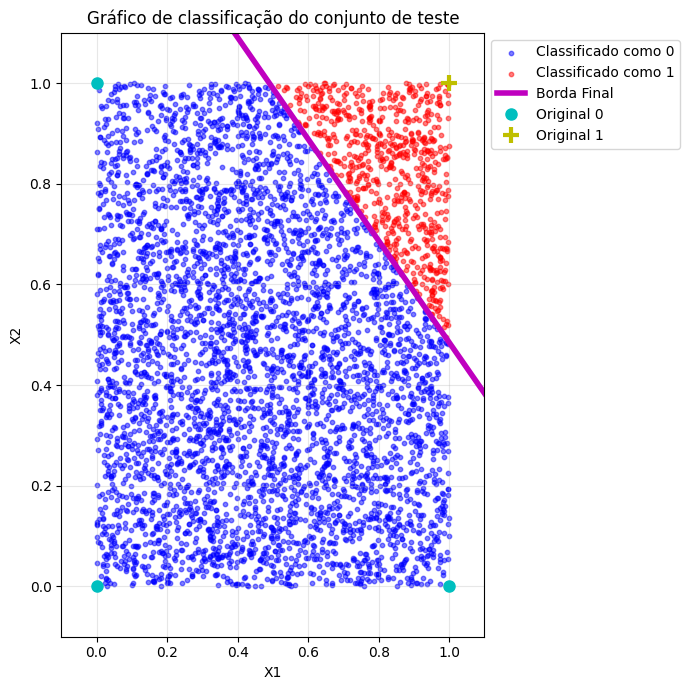

In [ ]:
# --- GERANDO O GRÁFICO DE CLASSIFICAÇÃO DO CONJUTO DE TESTE ---

def linear(x): # Implementação da função linear
  if x >= 0.5:
    return 1

  elif -0.5 <= x <= 0.5:
    return 0

# 1. Gerar milhares de pontos aleatórios entre 0 e 1 (área de interesse)
num_pontos = 5000
# Cria uma lista de 5000 valores aleatórios para o eixo horizontal (X1)
x_teste = np.random.rand(num_pontos) # Coordenadas X1

# Cria uma lista de 5000 valores aleatórios para o eixo vertical (X2)
y_teste = np.random.rand(num_pontos) # Coordenadas X2

# Listas para separar os pontos classificados
classe0_x, classe0_y = [], []
classe1_x, classe1_y = [], []

# 2. Usar os pesos e o bias final, já calculados, para classificar cada ponto

w1_final, w2_final = w # Atribuo o peso W1 e W2 para W1_final e W2_final
b_final = b # Atribuo o bias para o b_final.

for i in range(num_pontos):
    # Cálculo do somatório para o ponto aleatório
    soma_teste = (x_teste[i] * w1_final) + (y_teste[i] * w2_final) + b_final

    # Usando a função de ativação para definir as classes dos pontos aletorios
    if linear(soma_teste) == 1:
        classe1_x.append(x_teste[i])
        classe1_y.append(y_teste[i])
    else:
        classe0_x.append(x_teste[i])
        classe0_y.append(y_teste[i])

# 3. Plotagem
plt.figure(figsize=(7,7))

# Desenha a nuvem de pontos classificados
plt.scatter(classe0_x, classe0_y, color='blue', s=10, alpha=0.5, label='Classificado como 0')
plt.scatter(classe1_x, classe1_y, color='red', s=10, alpha=0.5, label='Classificado como 1')

# Desenha a Borda Final para referência
plt.plot(x_reta, y_final, 'm-', linewidth=4, label='Borda Final')

# Desenha os 4 pontos originais da porta AND por cima de tudo
plt.plot([0, 0, 1], [0, 1, 0], 'co', markersize=8, label='Original 0') # ciana
plt.plot([1], [1], 'y+', markersize=12, markeredgewidth=3, label='Original 1') # amarelo

plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.title("Gráfico de classificação do conjunto de teste")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusão:

## A partir do modelo ADALINE, observa-se que a curva de erro apresenta um decréscimo suave e assintótico, característico da aplicação do gradiente descendente na minimização do erro quadrático médio (MSE). Esse comportamento evidencia uma convergência eficaz no ajuste fino dos pesos e do bias.

##A validação por meio do conjunto de testes confirma que o treinamento foi adequado, demonstrando a capacidade de generalização do modelo diante de dados inéditos. Em suma, o Adaline mostrou-se eficiente e robusto para a resolução deste problema de classificação linearmente separável.